# Data Wrangling

Note: The usage of sklearn libraries will used at the end with a ColumnTransformer()

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [143]:
df = pd.read_csv("../data/raw/synthetic_coffee_health_10000.csv", index_col="ID") # Data comes with an ID column
df.head()

,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
ID,,,,,,,,,,,,,,,
1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


## Ordinal Encodings

One of the first things to notice is the variables```Healt_Issues```, ```Stress_Level```, and ```Sleep_Quality``` are ordinal variables (they have an order: i.e. *bad*, *neutral*, *good*). This requires a type of encoding that portrays the hierarchy between variables. This is best done with **Scikit-learn's** ```OrdinalEncoder()``` 

In [144]:
print(f"Stress_Level categories: {df.Stress_Level.unique()}") #This the ordinal categories for each variable
print(f"Sleep_Quality categories: {df.Sleep_Quality.unique()}") 
print(f"Healt_Issues categories: {df.Health_Issues.unique()}") #Includes Nans

Stress_Level categories: ['Low' 'Medium' 'High']
Sleep_Quality categories: ['Good' 'Fair' 'Excellent' 'Poor']
Healt_Issues categories: [nan 'Mild' 'Moderate' 'Severe']


As seen in the cell above, ```Health_Issues``` has missing values, this would usually be a problem, but not in this case. In the dataset's context, a nan in ```Health_Issues``` means that the user doesn't have any health issues. So we can just replace all nans with "None" or with the highest hierarchy in the category

In [145]:
df["Health_Issues"] = df["Health_Issues"].fillna("None") #Fills all Nans with None
print(f"New Health_Issues categories: {df.Health_Issues.unique()}")

New Health_Issues categories: ['None' 'Mild' 'Moderate' 'Severe']


## One-Hot encodings

Continuing with preprocessing, we still have some categories that aren't in numeric form.

In [146]:
transformed_columns = ["Stress_Level", "Sleep_Quality", "Health_Issues"]

object_columns = df.select_dtypes(include=["object"]).columns.to_list()
print(f"The variables that still aren't in number form are: {[column for column in object_columns if column not in transformed_columns]}")

The variables that still aren't in number form are: ['Gender', 'Country', 'Occupation']


In [147]:
print(f"Gender categories: {df.Gender.unique()}")
print(f"Country categories: {df.Country.unique()}")
print(f"Occupation categories: {df.Occupation.unique()}")

Gender categories: ['Male' 'Female' 'Other']
Country categories: ['Germany' 'Brazil' 'Spain' 'Mexico' 'France' 'Canada' 'UK' 'Switzerland'
 'Netherlands' 'Italy' 'China' 'Japan' 'Belgium' 'Finland' 'Australia'
 'USA' 'Sweden' 'India' 'Norway' 'South Korea']
Occupation categories: ['Other' 'Service' 'Office' 'Student' 'Healthcare']


Since ```Country``` has a lot of categories, we will try grouping countries by the continent to which they belong

In [148]:
countries_to_continents = {"Europe": ["Germany", "Spain", "France", "UK", "Switzerland", "Netherlands",
            "Italy", "Belgium", "Finland", "Sweeden", "Norway"],
 "Asia": ["China", "Japan", "South Korea", "India"],
 "America": ["Brazil", "Mexico", "Canada", "USA"],
 "Oceania": ["Australia"]}

countries_to_continents

{'Europe': ['Germany',
  'Spain',
  'France',
  'UK',
  'Switzerland',
  'Netherlands',
  'Italy',
  'Belgium',
  'Finland',
  'Sweeden',
  'Norway'],
 'Asia': ['China', 'Japan', 'South Korea', 'India'],
 'America': ['Brazil', 'Mexico', 'Canada', 'USA'],
 'Oceania': ['Australia']}

After assigning each country to its corresponding continent, we will manually create one-hot vectors using list comprehensions to create new variables in out dataset.

In [149]:
df["is_europe"] = [1 if country in countries_to_continents["Europe"] else 0
                for country in df["Country"]]

df["is_asia"] = [1 if country in countries_to_continents["Asia"] else 0
               for country in df["Country"]]

df["is_america"] = [1 if country in countries_to_continents["America"] else 0
                  for country in df["Country"]]

df["is_oceania"] = [1 if country in countries_to_continents["Oceania"] else 0
                  for country in df["Country"]]

In [150]:
country_df = df.drop("Country", axis=1) #Drop the no-longer useful "Country" column

In [151]:
country_df[["is_america", "is_asia", "is_europe", "is_oceania"]].head()

,is_america,is_asia,is_europe,is_oceania
ID,,,,
1,0,0,1,0
2,0,0,1,0
3,1,0,0,0
4,0,0,1,0
5,0,0,1,0


For ```Gender``` and ```Occupation``` a simple one-hot encoding will do

In [152]:
# The dtype of those columns can be changed to bool to optimize storage and byte-usage 
country_df["Smoking"] = country_df["Smoking"].astype(bool)
country_df["Alcohol_Consumption"] = country_df["Alcohol_Consumption"].astype(bool)

After all this encoding, all of our variables are encoded into numeric values, which allows our ML model to train on the data. But there is still some more preprocessing to do.

## Scaling Numeric Variables

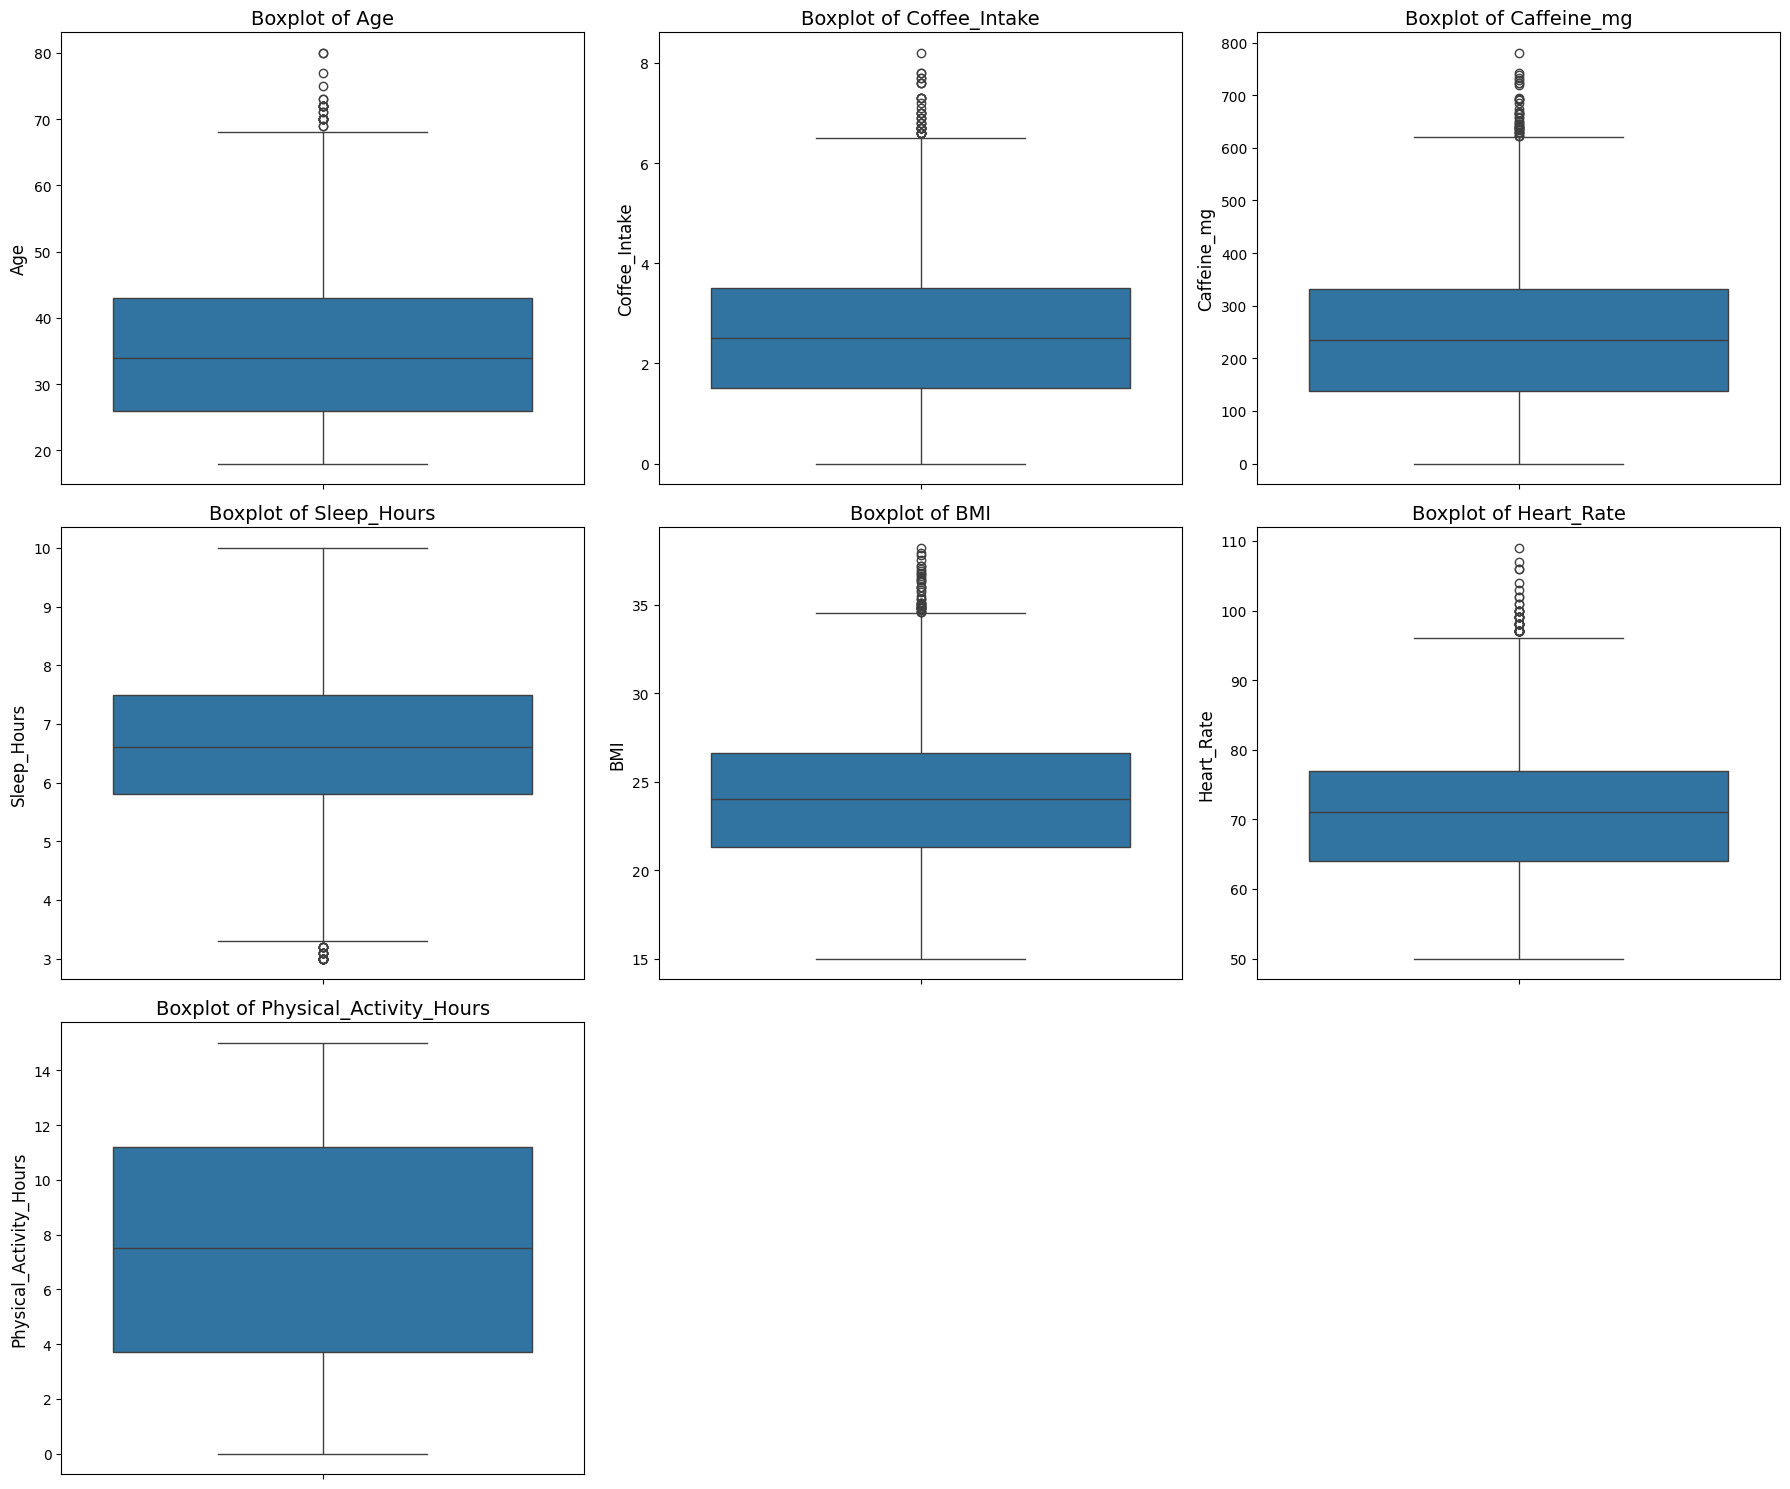

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the continuous and relevant integer columns for boxplots.
# Boxplots are generally not useful for ID, OHE (0/1), or nominal categorical columns.
numeric_cols = [
    'Age', 
    'Coffee_Intake', 
    'Caffeine_mg', 
    'Sleep_Hours', 
    'BMI', 
    'Heart_Rate', 
    'Physical_Activity_Hours'
]

# 2. Set up the figure and axes for the subplots
n_cols = 3 
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # Flatten the array for easy iteration

# 3. Generate a boxplot for each selected numerical column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=country_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_ylabel(col, fontsize=12)

# 4. Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() # In your local environment, this will display the plots.

since most of our remainding variables has outliers, our best option for scaling is a ```RobustScaler()``` since it uses IQ ranges to scale each value with the following formula:
$$
X_\text{scaled} = \frac{x_i - Q_1(x)}{Q_3 - Q_1}
$$

## Data Processing Pipeline

After analying all of the available columns, our dataset is ready to be transformed to a ML friendly format. ```ColumnTranformer()``` lets us automatize the preprocessing process, and further on implement this process in a fully developed ML Pipeline

In [154]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

numeric_cols = ['Age','Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours'] # Variables that have to be scaled

ordinal_categories = ["Stress_Level", "Sleep_Quality", "Health_Issues"] # Variables that have a hierarchical order

one_hot_categories = ["Gender", "Occupation"] # Variables that just need one-hot encoding

passthorugh = ["Smoking","Alcohol_Consumption", "is_asia", "is_america", "is_oceania", "is_europe"] # Variables that are already fine as they are

custom_categories = [["High", "Medium", "Low"], # Stress Level hierarchical order
                     ["Poor", "Fair", "Good", "Excellent"], # Sleep Quality hierarchical order
                     ["Severe", "Moderate", "Mild", "None"]] # Health Issues hierarchical order


ct = ColumnTransformer([
    ("robust_scaler", RobustScaler(), numeric_cols), # scaler
    ("ordinal_encoding", OrdinalEncoder(categories=custom_categories), ordinal_categories), #ordinal encoding
    ("onehot_encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories), #one hot encoding
    ("passthrough", "passthrough", passthorugh) #ignore
],
remainder="passthrough")

transformed_data = ct.fit_transform(country_df)
feature_names = ct.get_feature_names_out() #extract feature names

In [155]:
processed_df = pd.DataFrame(data=transformed_data, columns=feature_names) #This is the final dataframe with all processed variables
processed_df.head()

,robust_scaler__Age,robust_scaler__Coffee_Intake,robust_scaler__Caffeine_mg,robust_scaler__Sleep_Hours,robust_scaler__BMI,robust_scaler__Heart_Rate,robust_scaler__Physical_Activity_Hours,ordinal_encoding__Stress_Level,ordinal_encoding__Sleep_Quality,ordinal_encoding__Health_Issues,...,onehot_encoding__Occupation_Office,onehot_encoding__Occupation_Other,onehot_encoding__Occupation_Service,onehot_encoding__Occupation_Student,passthrough__Smoking,passthrough__Alcohol_Consumption,passthrough__is_asia,passthrough__is_america,passthrough__is_oceania,passthrough__is_europe
0,0.352941,0.5,0.479627,0.529412,0.169811,0.538462,0.933333,2.0,2.0,3.0,...,0.0,1.0,0.0,0.0,False,False,0,0,0,1
1,-0.058824,-0.75,-0.731083,-0.235294,-0.754717,-0.307692,0.466667,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,False,False,0,0,0,1
2,0.470588,1.4,1.388177,-0.411765,-0.245283,-0.923077,0.493333,1.0,1.0,2.0,...,1.0,0.0,0.0,0.0,False,False,0,1,0,0
3,1.117647,0.05,0.071401,0.411765,0.132075,0.0,-0.12,2.0,2.0,2.0,...,0.0,1.0,0.0,0.0,False,False,0,0,0,1
4,-0.117647,0.3,0.323891,-0.764706,0.018868,0.384615,0.133333,1.0,1.0,2.0,...,0.0,0.0,0.0,1.0,False,True,0,0,0,1


In [156]:
processed_df.to_csv("../data/processed/processed_coffee_data.csv", index=True)

In [157]:
processed_df.head()

,robust_scaler__Age,robust_scaler__Coffee_Intake,robust_scaler__Caffeine_mg,robust_scaler__Sleep_Hours,robust_scaler__BMI,robust_scaler__Heart_Rate,robust_scaler__Physical_Activity_Hours,ordinal_encoding__Stress_Level,ordinal_encoding__Sleep_Quality,ordinal_encoding__Health_Issues,...,onehot_encoding__Occupation_Office,onehot_encoding__Occupation_Other,onehot_encoding__Occupation_Service,onehot_encoding__Occupation_Student,passthrough__Smoking,passthrough__Alcohol_Consumption,passthrough__is_asia,passthrough__is_america,passthrough__is_oceania,passthrough__is_europe
0,0.352941,0.5,0.479627,0.529412,0.169811,0.538462,0.933333,2.0,2.0,3.0,...,0.0,1.0,0.0,0.0,False,False,0,0,0,1
1,-0.058824,-0.75,-0.731083,-0.235294,-0.754717,-0.307692,0.466667,2.0,2.0,3.0,...,0.0,0.0,1.0,0.0,False,False,0,0,0,1
2,0.470588,1.4,1.388177,-0.411765,-0.245283,-0.923077,0.493333,1.0,1.0,2.0,...,1.0,0.0,0.0,0.0,False,False,0,1,0,0
3,1.117647,0.05,0.071401,0.411765,0.132075,0.0,-0.12,2.0,2.0,2.0,...,0.0,1.0,0.0,0.0,False,False,0,0,0,1
4,-0.117647,0.3,0.323891,-0.764706,0.018868,0.384615,0.133333,1.0,1.0,2.0,...,0.0,0.0,0.0,1.0,False,True,0,0,0,1


# Dropping Variables

As we stated in _01_eda_inicial, the variables we are going to drop are:

- robust_scaler_Coffe_Intake
- robust_scaler__Sleep_Hours
- onehot_encoding__Gender_Other
- onehot_encoding__Occupation_Other
- passtrough_is_oceania
- ordinal_encoding__Health_Issues
- ordinal_encoding__Stress_Level

In [158]:
columns_to_drop = [
    "robust_scaler__Coffee_Intake",
    "onehot_encoding__Gender_Other",
    "onehot_encoding__Occupation_Other",
    "passthrough__is_oceania",
    "robust_scaler__Sleep_Hours",
    "ordinal_encoding__Stress_Level",
    "ordinal_encoding__Health_Issues"]

processed_df.drop(columns=columns_to_drop, inplace=True)
processed_df.head()

,robust_scaler__Age,robust_scaler__Caffeine_mg,robust_scaler__BMI,robust_scaler__Heart_Rate,robust_scaler__Physical_Activity_Hours,ordinal_encoding__Sleep_Quality,onehot_encoding__Gender_Female,onehot_encoding__Gender_Male,onehot_encoding__Occupation_Healthcare,onehot_encoding__Occupation_Office,onehot_encoding__Occupation_Service,onehot_encoding__Occupation_Student,passthrough__Smoking,passthrough__Alcohol_Consumption,passthrough__is_asia,passthrough__is_america,passthrough__is_europe
0,0.352941,0.479627,0.169811,0.538462,0.933333,2.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,0,0,1
1,-0.058824,-0.731083,-0.754717,-0.307692,0.466667,2.0,0.0,1.0,0.0,0.0,1.0,0.0,False,False,0,0,1
2,0.470588,1.388177,-0.245283,-0.923077,0.493333,1.0,0.0,1.0,0.0,1.0,0.0,0.0,False,False,0,1,0
3,1.117647,0.071401,0.132075,0.0,-0.12,2.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,0,0,1
4,-0.117647,0.323891,0.018868,0.384615,0.133333,1.0,1.0,0.0,0.0,0.0,0.0,1.0,False,True,0,0,1


<Axes: >

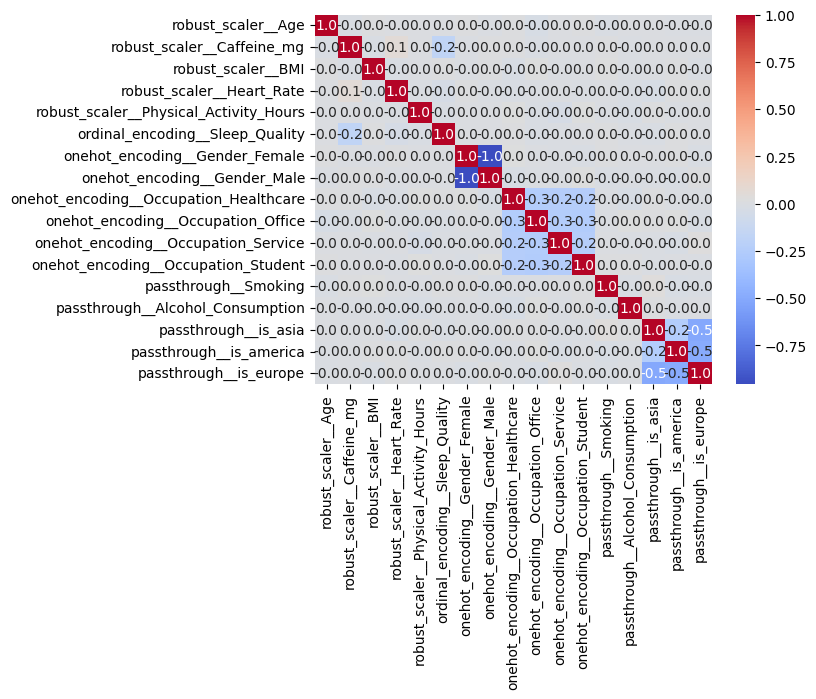

In [159]:
sns.heatmap(processed_df.corr(), annot=True, fmt=".1f", cmap="coolwarm")

# Data Balancing

In [160]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

try:
    df = processed_df  # Usando el DataFrame ya procesado
except FileNotFoundError:
    print("Error: No encontré 'tu_archivo_de_datos.csv'.")
    df = pd.DataFrame({
        'robust_scaler__Caffeine mg': [100, 50, 0, 200, 10, 50],
        'alguna_otra_feature': [1, 2, 3, 1, 2, 3],
        'ordinal_encoding__Sleep Quality': [0.0, 1.0, 2.0, 0.0, 1.0, float('nan')] 
    })


TARGET_COLUMN = 'ordinal_encoding__Sleep_Quality'

# Creamos un fix para asegurarnos que el target este limpio
# evitando errores en el preprocesamiento y modelado.
print("--- Diagnóstico de la Columna Objetivo (ANTES) ---")
print(df[TARGET_COLUMN].info())
print(f"Valores nulos: {df[TARGET_COLUMN].isna().sum()}")
print(f"Valores únicos: {df[TARGET_COLUMN].unique()}\n")

rows_before = df.shape[0]
df.dropna(subset=[TARGET_COLUMN], inplace=True)
rows_after = df.shape[0]

if rows_before > rows_after:
    print(f"Se eliminaron {rows_before - rows_after} filas con valores nulos en '{TARGET_COLUMN}'.\n")

df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

print("--- Diagnóstico de la Columna Objetivo (DESPUÉS DEL FIX) ---")
print(df[TARGET_COLUMN].info())
print(f"Valores únicos ahora: {df[TARGET_COLUMN].unique()}\n")

y = df[TARGET_COLUMN]

X = df.drop(columns=[TARGET_COLUMN])
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])

# 1. Dividir en Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Diagnóstico (Antes): Muestra el desbalanceo en el set de entrenamiento
print("--- ANTES de SMOTE (en set de entrenamiento) ---")
print(Counter(y_train))

# 2. Aplicar SMOTE a los datos de entrenamiento
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verificación (Despues): Muestra los nuevos conteos
print("\n--- DESPUES de SMOTE (en set de entrenamiento) ---")
print(Counter(y_train_res))

print("\nDatos listos para comenzar a modelar.")

--- Diagnóstico de la Columna Objetivo (ANTES) ---
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: ordinal_encoding__Sleep_Quality
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB
None
Valores nulos: 0
Valores únicos: [2.0 1.0 3.0 0.0]

--- Diagnóstico de la Columna Objetivo (DESPUÉS DEL FIX) ---
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: ordinal_encoding__Sleep_Quality
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB
None
Valores únicos ahora: [2 1 3 0]

--- ANTES de SMOTE (en set de entrenamiento) ---
Counter({2: 3901, 1: 1484, 3: 949, 0: 666})

--- DESPUES de SMOTE (en set de entrenamiento) ---
Counter({3: 3901, 2: 3901, 0: 3901, 1: 3901})

Datos listos para comenzar a modelar.


# Pipeline creation

In [161]:
print(X_train.columns)

Index(['robust_scaler__Age', 'robust_scaler__Caffeine_mg',
       'robust_scaler__BMI', 'robust_scaler__Heart_Rate',
       'robust_scaler__Physical_Activity_Hours',
       'onehot_encoding__Gender_Female', 'onehot_encoding__Gender_Male',
       'onehot_encoding__Occupation_Healthcare',
       'onehot_encoding__Occupation_Office',
       'onehot_encoding__Occupation_Service',
       'onehot_encoding__Occupation_Student', 'passthrough__Smoking',
       'passthrough__Alcohol_Consumption', 'passthrough__is_asia',
       'passthrough__is_america', 'passthrough__is_europe'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
# Añadido para una evaluación más completa
from sklearn.metrics import classification_report, accuracy_score

# Columna del target a predecir
TARGET_COLUMN = 'Sleep_Quality'

class DataWrangler(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado para:
    1. Llenar NaNs en 'Health_Issues' con 'None'.
    2. Mapear 'Country' a columnas de continentes.
    """
    def __init__(self):
        # mapeo de paises a continentes realizado anteriormente
        self.countries_to_continents = {
            "Europe": ["Germany", "Spain", "France", "UK", "Switzerland", "Netherlands",
                       "Italy", "Belgium", "Finland", "Sweeden", "Norway"],
            "Asia": ["China", "Japan", "South Korea", "India"],
            "America": ["Brazil", "Mexico", "Canada", "USA"],
            "Oceania": ["Australia"]
        }

    def fit(self, X, y=None):
        # el metodo fit si bien no hace nada, es necesario para el pipeline 
        return self
    
    def transform(self, X, y=None):
        # Asegurarse de que estamos trabajando con una copia
        X_ = X.copy()
        
        # 1. Llenar NaNs en Health_Issues
        if 'Health_Issues' in X_.columns:
            X_["Health_Issues"] = X_["Health_Issues"].fillna("None")
        
        # 2. Mapeo de Continentes
        if 'Country' in X_.columns:
            X_["is_europe"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Europe"] else 0)
            X_["is_asia"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Asia"] else 0)
            X_["is_america"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["America"] else 0)
            X_["is_oceania"] = X_['Country'].apply(lambda x: 1 if x in self.countries_to_continents["Oceania"] else 0)
            
            # Eliminamos la columna original 'Country'
            X_ = X_.drop("Country", axis=1)
            
        return X_

# 1. Numericas (RobustScaler)
numeric_cols = ['Age', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

# 2. Ordinales (OrdinalEncoder)
# --- CORRECCIÓN 1 ---
# 'Sleep_Quality' se elimina de aquí porque es el TARGET (y), no una feature (X).
ordinal_categories_cols = ["Stress_Level", "Health_Issues"]

# --- CORRECCIÓN 2 ---
# Se elimina la lista de categorías de 'Sleep_Quality' para que coincida con la lista de arriba.
custom_categories = [
    ["Low", "Medium", "High"],                 # Para Stress_Level
    ["None", "Mild", "Moderate", "Severe"]    # Para Health_Issues
]

# 3. Nominales (OneHotEncoder)
one_hot_categories = ["Gender", "Occupation"]

# 4. Passthrough 
passthrough_cols = ["Smoking", "Alcohol_Consumption", "is_asia", "is_america", "is_europe"]


preprocessor = ColumnTransformer(
    transformers=[
        ("robust_scaler", RobustScaler(), numeric_cols),
        ("ordinal_encoding", OrdinalEncoder(categories=custom_categories), ordinal_categories_cols),
        ("onehot_encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first'), one_hot_categories),
        ("passthrough", "passthrough", passthrough_cols)
    ],
    remainder="drop" # Esto dropearo 'Coffee_Intake' y 'is_oceania' (creada por el wrangler)
)

# Creamos el pipeline completo usando imblearn
full_pipeline = Pipeline(steps=[
    ('data_wrangler', DataWrangler()),      # 1. Limpieza (fillna, continentes)
    ('preprocessor', preprocessor),         # 2. ColumnTransformer (scaling, encoding)
    ('sampler', SMOTE(random_state=42)),    # 3. Balanceo SMOTE 
    ('classifier', LogisticRegression(max_iter=1000)) # 4. Modelo a usar (aumentado max_iter)
])

# 1. Cargamos los datos raw sin procesar
df_raw = pd.read_csv("../data/raw/synthetic_coffee_health_10000.csv", index_col="ID")

# 2. Definimos las features y el target
# Mapeamos 'y' (target) a números ANTES de pasarlo al pipeline.
# SMOTE y LogisticRegression lo necesitan.
y_map = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
y = df_raw[TARGET_COLUMN].map(y_map)

X = df_raw.drop(TARGET_COLUMN, axis=1)

# 3. Dividimos en Train/Test 80/20
#    Añadido 'stratify=y' para asegurar que la distribución de clases sea la misma 
#    en train y test, lo cual es crucial para datos desbalanceados.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Ejecutamos el pipeline completo
print("--- Entrenando el Pipeline completo... ---")
full_pipeline.fit(X_train, y_train)
print("--- Pipeline entrenado con exito... ---")

# 5. Evalua 
y_pred = full_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy en el Test set: {accuracy:.4f}\n")
print("--- Reporte de Clasificación en Test Set ---")
print(classification_report(y_test, y_pred, target_names=y_map.keys()))

--- Entrenando el Pipeline completo... ---
--- Pipeline entrenado con exito... ---

Accuracy en el Test set: 0.9900

--- Reporte de Clasificación en Test Set ---
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       1.00      0.98      0.99      1128
   Excellent       0.94      0.99      0.96       270

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

